In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper functions
from helper_functions import (
    load_signal_data,
    extract_operating_periods,
    extract_steady_states_from_windows,
    test_dbscan_eps,
    make_window_features,
    clean_signals,
    extract_steady_states_by_threshold,
    get_interval_mask,
    build_model_df,
    build_model_window_df,
    get_signal_df,
    _window_mean
)


Loading csv files from folder

In [3]:
folder = "step_interpolation_10s/G2_relevant"

dfs = load_signal_data(
    search_folder=folder
)

Cleaning the data

In [4]:
dfs, cleaning_table = clean_signals(dfs)

cleaning_table

,Signal,Invalid values,Invalid [%]
0,Turbine inlet pressure,759,0.0578
1,DE Bearing temp,4,0.0003
2,DE Bearing oil temp,10,0.0008
3,DE Vibration,3,0.0002


Defining the speed, power and vibration dataframes

In [5]:
speed_name = "Rotational speed"
power_name = "Generator active power"
vib_name = "DE Vibration"
field_current_name = "Exciter current"
pos_name = "Total needle opening position"
inletp_name = "Turbine inlet pressure"
setpoint_name = "Set point"


speed = get_signal_df(dfs, speed_name)
power = get_signal_df(dfs, power_name)
vib = get_signal_df(dfs, vib_name)
field_current = get_signal_df(dfs, field_current_name)
pos = get_signal_df(dfs, pos_name)
inletp = get_signal_df(dfs, inletp_name)
setpoint = get_signal_df(dfs, setpoint_name)


In [34]:
model_1min = pd.read_csv(
    "steady_state_model_dataset_1min.csv",
    parse_dates=["start_time", "end_time"]
)

model_1min = model_1min.sort_values("start_time").reset_index(drop=True)

In [35]:
print(model_1min.shape)
print(model_1min.columns)
model_1min.head()

(209104, 14)
Index(['operating_period', 'start_time', 'end_time', 'power', 'power_std',
       'start_idx', 'end_idx', 'is_steady', 'interval_id', 'speed', 'position',
       'field_current', 'inlet_pressure', 'vibration'],
      dtype='object')


,operating_period,start_time,end_time,power,power_std,start_idx,end_idx,is_steady,interval_id,speed,position,field_current,inlet_pressure,vibration
0,0,2024-06-01 00:00:00,2024-06-01 00:00:50,9.429999,0.0,0,5,True,1,100.046741,75.339462,6.948219,3826.189043,0.586103
1,0,2024-06-01 00:01:00,2024-06-01 00:01:50,9.429999,0.0,6,11,True,1,99.991665,74.975650,6.953729,3826.189043,0.618846
2,0,2024-06-01 00:02:00,2024-06-01 00:02:50,9.429999,0.0,12,17,True,1,99.977175,75.124611,6.959528,3826.189043,0.618846
3,0,2024-06-01 00:03:00,2024-06-01 00:03:50,9.429999,0.0,18,23,True,1,99.971610,75.124611,6.954519,3826.189043,0.618846
4,0,2024-06-01 00:04:00,2024-06-01 00:04:50,9.429999,0.0,24,29,True,1,99.968010,75.124611,6.950508,3826.189043,0.618846


In [53]:
features = [
    "power",
    "field_current",
    "inlet_pressure",
    "position"
]

target = "vibration"


In [54]:
X = model_1min[features]
y = model_1min[target]

In [55]:
ann_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ann", MLPRegressor(
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
        early_stopping=False
    ))
])

In [46]:
split_idx = int(len(X) * 0.70)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [47]:
param_grid = {
    "ann__hidden_layer_sizes": [
        (16,),
        (32,),
        (32, 16),
        (64, 32),
    ],
    "ann__alpha": [
        0.0001,
        0.001,
        0.01,
    ],
    "ann__learning_rate_init": [
        0.001,
        0.0005,
    ],
}

In [48]:
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=ann_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann__learning_rate_init=0.001; total time=   0.6s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.001; total time=   0.5s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.0005; total time=   0.6s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann__learning_rate_init=0.0005; total time=   0.9s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.001; total time=   1.1s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann__learning_rate_init=0.001; total time=   1.2s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann__learning_rate_init=0.0005; total time=   1.4s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(32,), ann__learning_rate_init=0.001; total time=   1.4s
[CV] END ann__alpha=0.0001, ann__hidden_layer_sizes=(16,), ann_

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'ann__alpha': [0.0001, 0.001, ...], 'ann__hidden_layer_sizes': [(16,), (32,), ...], 'ann__learning_rate_init': [0.001, 0.0005]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [49]:
best_ann = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print(f"Best CV RMSE: {-grid_search.best_score_:.4f} mm/s RMS")

Best parameters:
{'ann__alpha': 0.01, 'ann__hidden_layer_sizes': (64, 32), 'ann__learning_rate_init': 0.0005}
Best CV RMSE: 0.0405 mm/s RMS


In [50]:
y_pred = best_ann.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE:  {mae:.4f} mm/s RMS")
print(f"Test RMSE: {rmse:.4f} mm/s RMS")
print(f"Test R²:   {r2:.4f}")

Test MAE:  0.0416 mm/s RMS
Test RMSE: 0.0552 mm/s RMS
Test R²:   0.5363


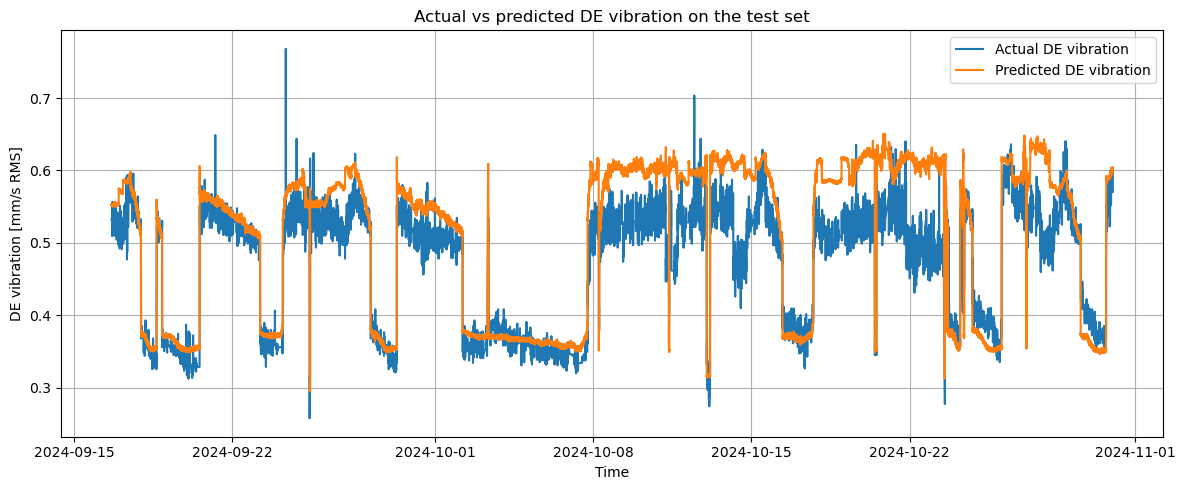

In [51]:
results_ann = pd.DataFrame({
    "start_time": model_1min.loc[X_test.index, "start_time"].values,
    "actual": y_test.values,
    "predicted": y_pred,
})

plt.figure(figsize=(12, 5))
plt.plot(results_ann["start_time"], results_ann["actual"], label="Actual DE vibration")
plt.plot(results_ann["start_time"], results_ann["predicted"], label="Predicted DE vibration")

plt.xlabel("Time")
plt.ylabel("DE vibration [mm/s RMS]")
plt.title("Actual vs predicted DE vibration on the test set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

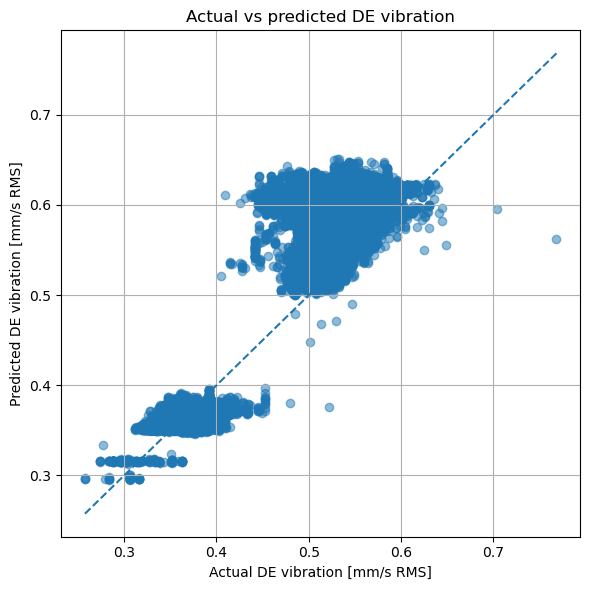

In [52]:
plt.figure(figsize=(6, 6))
plt.scatter(results_ann["actual"], results_ann["predicted"], alpha=0.5)

min_val = min(results_ann["actual"].min(), results_ann["predicted"].min())
max_val = max(results_ann["actual"].max(), results_ann["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual DE vibration [mm/s RMS]")
plt.ylabel("Predicted DE vibration [mm/s RMS]")
plt.title("Actual vs predicted DE vibration")
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import PredictionErrorDisplay
import matplotlib.pyplot as plt

PredictionErrorDisplay.from_estimator(
    best_ann,
    X_test,
    y_test,
    kind="actual_vs_predicted"
)

plt.title("Actual vs predicted DE vibration")
plt.tight_layout()
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- power_std


In [27]:
y_baseline = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))
baseline_r2 = r2_score(y_test, y_baseline)

print(f"Baseline MAE:  {baseline_mae:.4f} mm/s RMS")
print(f"Baseline RMSE: {baseline_rmse:.4f} mm/s RMS")
print(f"Baseline R²:   {baseline_r2:.4f}")

Baseline MAE:  0.0663 mm/s RMS
Baseline RMSE: 0.0909 mm/s RMS
Baseline R²:   -0.2583
